# Six-Pack of Persistence Diagrams — Vietoris–Rips Filtration

Cohen-Steiner, Edelsbrunner, Harer, Morozov (SODA 2009)의 알고리즘을 이용해  
두 점군 A, B 에 대한 포함 관계 `L = Rips(A) ⊆ K = Rips(A∪B)` 에서  
**Six-Pack** (Image / Kernel / Cokernel / H*(K) / H*(L) / H*(K,L)) 을 계산합니다.

---
### 수학적 배경

| 기호 | 의미 |
|------|------|
| K | Rips(A∪B) — 전체 복합체 |
| L | Rips(A) — 서브복합체 |
| f* | H*(L) → H*(K), 포함 유도 호몰로지 맵 |
| Im(f*) | Image persistence |
| Ker(f*) | Kernel persistence |
| Cok(f*) | Cokernel persistence |
| H*(K,L) | 상대 호몰로지 |

---
### 행렬 소거 순서 (논문 Algorithm 1 & 2)

1. **Df** (K의 boundary) → Rf, Vf  
2. **Dg** (L의 boundary, L-인덱스) → Rg, Vg  
3. **Dim** (Df의 행을 L-먼저 재정렬) → Rim (lowim)  
4. **Dker** = { Vf[c] | Rim[c] = 0 } → lowker  
5. **Dcok** (positive-in-Rg 열을 Vg로 교체) → lowcok  
6. **Drel** (K\L의 boundary를 K\L 행만 남김) → lowrel  *(← 이번에 추가)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gudhi import RipsComplex
from collections import defaultdict
from persim import PersistenceImager
import persim.images_weights as weights

## 1. 기본 함수: Rips Filtration & 행렬 소거

In [15]:
def compute_Rips(points, max_edge=10):
    """Rips complex 계산 (GUDHI)."""
    rips = RipsComplex(points=points, max_edge_length=max_edge)
    st = rips.create_simplex_tree(max_dimension=2)
    return st


def divide_filtration(st):
    """SimplexTree에서 (simplex, filtration값) 리스트 추출."""
    pairs = [(tuple(sorted(s)), f) for s, f in st.get_filtration()]
    simplices = [p[0] for p in pairs]
    filt     = [p[1] for p in pairs]
    return simplices, filt


def _build_boundary(simplices):
    """Boundary matrix 구성 (Z/2Z, set 표현)."""
    sf_to_idx = {s: i for i, s in enumerate(simplices)}
    boundary  = []
    for s in simplices:
        if len(s) <= 1:
            boundary.append(set())
        else:
            rows = set()
            for j in range(len(s)):
                face = s[:j] + s[j+1:]
                if face in sf_to_idx:
                    rows.add(sf_to_idx[face])
            boundary.append(rows)
    return boundary

## 2. Six-Pack 계산 함수

`compute_all_barcodes(A, B)` : Image / Kernel / Cokernel / H*(K,L) 계산  
`compute_persistence_barcode(pts)` : 표준 H*(K) 및 H*(L) 계산

In [16]:
def compute_relative_barcode_only(A, B, max_edge=10):
    """
    Inclusion L = Rips(A) ⊆ K = Rips(A∪B) 에 대한 
    Relative Persistence Barcode (H*(K,L))를 효율적으로 계산합니다.
    """
    total = np.concatenate([A, B], axis=0)
    a_len = len(A)

    # 1. Rips complex 계산 및 Filtration 추출 (GUDHI)
    st = compute_Rips(total, max_edge=max_edge)
    simplices, filt = divide_filtration(st)
    
    # 2. K\L 심플렉스 인덱스 분류
    # 심플렉스의 모든 vertex가 A군(index < a_len)에 있으면 L에 속함. 
    # 하나라도 B군에 있으면 K\L에 속함.
    idx_KmL = [i for i, s in enumerate(simplices) if any(v >= a_len for v in s)]
    set_idx_KmL = set(idx_KmL)
    
    # Global index를 K\L 내의 Local index로 매핑
    KmL_pos = {g_idx: l_idx for l_idx, g_idx in enumerate(idx_KmL)}
    
    # 3. Relative Boundary Matrix 직접 구축 (C*(K)/C*(L))
    # Df 전체를 만들지 않고 필요한 부분만 생성하여 메모리와 시간 절약
    sf_to_idx = {s: i for i, s in enumerate(simplices)}
    Drel = []
    for g_idx in idx_KmL:
        s = simplices[g_idx]
        rows = set()
        if len(s) > 1:
            for j in range(len(s)):
                face = s[:j] + s[j+1:]
                face_idx = sf_to_idx.get(face)
                if face_idx in set_idx_KmL:
                    rows.add(KmL_pos[face_idx])
        Drel.append(rows)

    # 4. 최적화된 행렬 소거 (V 행렬 계산 제외)
    def _reduce_fast(columns):
        m = len(columns)
        R = [set(col) for col in columns]
        low = [-1] * m
        pivot_of_row = {}
        for i in range(m):
            while R[i]:
                li = max(R[i])
                if li in pivot_of_row:
                    R[i] ^= R[pivot_of_row[li]]
                else:
                    pivot_of_row[li] = i
                    low[i] = li
                    break
        return R, low

    Rrel, lowrel = _reduce_fast(Drel)

    # 5. Barcode 추출
    def _format(bars_dict):
        out = {}
        for p in [0, 1, 2]: # 필요한 차원까지 확장 가능
            if p in bars_dict and bars_dict[p]:
                arr = np.array(bars_dict[p])
                out[p] = arr[np.lexsort((arr[:, 1], arr[:, 0]))]
            else:
                out[p] = np.empty((0, 2))
        return out

    rel_bars = defaultdict(list)
    for pos in range(len(idx_KmL)):
        if lowrel[pos] != -1:
            sigma_local = lowrel[pos]
            sigma = idx_KmL[sigma_local]
            tau = idx_KmL[pos]
            b, d = filt[sigma], filt[tau]
            if abs(b - d) > 1e-12:
                p = len(simplices[sigma]) - 1
                rel_bars[p].append((b, d))

    return {'relative': _format(rel_bars)}

## 3. Persistence Image 변환 함수

In [17]:
def compute_PIs(barcodes, max_eps=10, px_res=0.1, sigma=0.05, normalization=False):
    """Barcode → Persistence Image 벡터 변환."""
    for key in barcodes:
        if len(barcodes[key]) == 0:
            barcodes[key] = np.zeros((0, 2))

    vector = {}

    # H0: birth_range=(0,1), pers_range=(0,max_eps), skew=False, mean over birth axis
    pi0 = PersistenceImager(pixel_size=px_res,
                            birth_range=(0, 1),
                            pers_range=(0, max_eps),
                            weight=weights.persistence,
                            weight_params={'n': 1},
                            kernel_params={'sigma': [[sigma, 0], [0, sigma]]})
    bars0 = np.array(barcodes[0])
    img0  = pi0.transform(bars0, skew=False) if len(bars0) > 0 else np.zeros((int(1/px_res), int(max_eps/px_res)))
    img0_1d = np.mean(img0, axis=0)

    # H1: birth_range=(0,max_eps), pers_range=(0,max_eps/2), skew=True
    pi1 = PersistenceImager(pixel_size=px_res,
                            birth_range=(0, max_eps),
                            pers_range=(0, max_eps / 2),
                            weight=weights.persistence,
                            weight_params={'n': 1},
                            kernel_params={'sigma': [[sigma, 0], [0, sigma]]})
    bars1 = np.array(barcodes[1])
    img1  = pi1.transform(bars1, skew=True) if len(bars1) > 0 else np.zeros((int(max_eps/px_res), int((max_eps/2)/px_res)))

    if normalization:
        vector[0] = img0_1d / np.max(img0_1d) if np.max(img0_1d) > 0 else img0_1d
        vector[1] = img1.flatten() / np.max(img1) if np.max(img1) > 0 else img1.flatten()
    else:
        vector[0] = img0_1d
        vector[1] = img1.flatten()
    return vector


def visualize_six_pack_PIs(PI_dict, max_eps=10, px_res=0.1, figsize=(18, 10)):
    """Six-pack 전체 (6개 그룹)의 Persistence Image 시각화."""
    groups = ['image', 'kernel', 'cokernel', 'relative', 'complex', 'sub_complex']
    labels = ['Image  Im(f*)', 'Kernel  Ker(f*)', 'Cokernel  Cok(f*)',
              'Relative  H*(K,L)', 'Full Complex  H*(K)', 'Sub-Complex  H*(L)']

    fig, axes = plt.subplots(len(groups), 2, figsize=figsize)
    h1_bins = (int(max_eps/px_res), int((max_eps/2)/px_res))

    for row, (g, lbl) in enumerate(zip(groups, labels)):
        if g not in PI_dict:
            for ax in axes[row]:
                ax.set_visible(False)
            continue
        PIs = PI_dict[g]
        h0  = PIs[0]
        h1  = PIs[1].reshape(h1_bins)

        ax0, ax1 = axes[row]
        ax0.plot(h0, linewidth=1.5)
        ax0.fill_between(range(len(h0)), h0, alpha=0.3)
        ax0.set_title(f'{lbl}  —  H0')
        ax0.set_xlabel('Persistence bin')
        ax0.grid(alpha=0.3)

        im = ax1.imshow(h1.T, cmap='hot', origin='lower', aspect='auto')
        ax1.set_title(f'{lbl}  —  H1')
        ax1.set_xlabel('Birth bin')
        ax1.set_ylabel('Persistence bin')
        plt.colorbar(im, ax=ax1)

    plt.tight_layout()
    plt.show()

## 4. 데이터 생성

In [ ]:
A = np.random.rand(120, 2) * 20   # 점군 A  (서브복합체 L = Rips(A))
B = np.random.rand(80,  2) * 20   # 점군 B  (전체 = Rips(A∪B))

## 5. Six-Pack 계산

In [19]:
MAX_EDGE = 10   # Rips complex 최대 엣지 길이 (조정 가능)

# Image / Kernel / Cokernel / Relative (H*(K,L))
relative_A_to_B = compute_relative_barcode_only(A, B, max_edge=MAX_EDGE)
relative_B_to_A = compute_relative_barcode_only(B, A, max_edge=MAX_EDGE)


# 결과 미리보기
for name, sp in [('A→B', relative_A_to_B), ('B→A', relative_B_to_A)]:
    print(f'\n=== Six-Pack ({name}) ===')
    for key in ['relative']:
        h0 = len(sp[key][0]) if 0 in sp[key] else 0
        h1 = len(sp[key][1]) if 1 in sp[key] else 0
        print(f'  {key:<12}  H0: {h0:3d} bars,  H1: {h1:3d} bars')


=== Six-Pack (A→B) ===
  relative      H0:  80 bars,  H1:  71 bars

=== Six-Pack (B→A) ===
  relative      H0: 120 bars,  H1:  77 bars


## 6. Persistence Image 변환

In [20]:
PI_A_to_B = {}
PI_B_to_A = {}

for key in relative_A_to_B:
    PI_A_to_B[key] = compute_PIs(relative_A_to_B[key],
                                  max_eps=MAX_EDGE*2, px_res=0.1, sigma=0.05)
    PI_B_to_A[key] = compute_PIs(relative_B_to_A[key],
                                  max_eps=MAX_EDGE*2, px_res=0.1, sigma=0.05)

## 7. Six-Pack 시각화 (A → B)

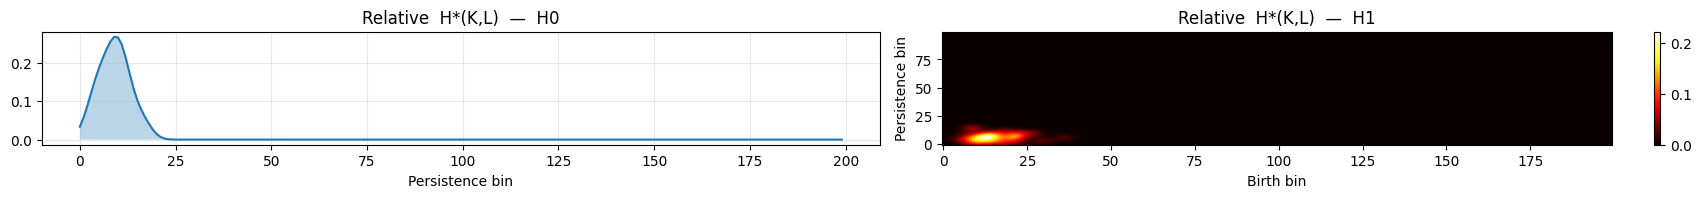

In [21]:
visualize_six_pack_PIs(PI_A_to_B, max_eps=MAX_EDGE*2, px_res=0.1)

## 8. Six-Pack 시각화 (B → A)

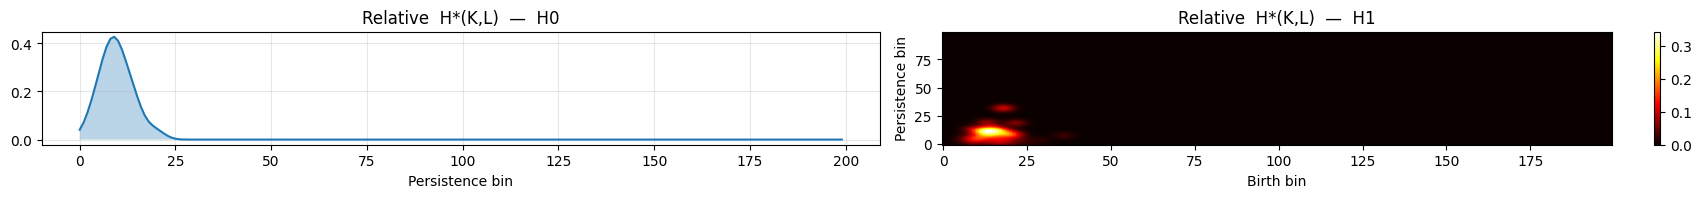

In [22]:
visualize_six_pack_PIs(PI_B_to_A, max_eps=MAX_EDGE*2, px_res=0.1)